# Crop Recommendation Workflow

This notebook documents the full machine learning workflow used in the Symfony field management integration.

It covers:
- dataset loading and quick exploration
- train/validation/test split
- comparison of at least 3 candidate models
- model selection and test evaluation
- feature importance and class profiles
- export of production artifacts
- explainable recommendation output

In [3]:
%pip install joblib scikit-learn matplotlib

from __future__ import annotations

from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"

def resolve_project_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "Crop_recommendation.csv").is_file():
        return cwd
    if (cwd.parent / "Crop_recommendation.csv").is_file():
        return cwd.parent
    return cwd

def as_float(value: float) -> float:
    return float(np.round(float(value), 6))

PROJECT_ROOT = resolve_project_root()
DATASET_PATH = PROJECT_ROOT / "Crop_recommendation.csv"
ARTIFACT_DIR = PROJECT_ROOT / "ml" / "crop_recommendation"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.1 MB 4.4 MB/s eta 0:00:02
   ----------- --------------------------

WindowsPath('c:/Users/youss/OneDrive/Bureau/My Projects/symfony-agriculturefinale-20260410-0258/Crop_recommendation.csv')

## 1) Load and Inspect Data

In [4]:
df = pd.read_csv(DATASET_PATH)
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print("Columns:", list(df.columns))

missing = [c for c in FEATURES + [TARGET] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

for feature in FEATURES:
    df[feature] = pd.to_numeric(df[feature], errors="coerce")

df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
df[TARGET] = df[TARGET].astype(str)

df[FEATURES].describe().T

Rows: 2200 | Columns: 8
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [6]:
label_counts = df[TARGET].value_counts().sort_index()
label_counts

label
apple          100
banana         100
blackgram      100
chickpea       100
coconut        100
coffee         100
cotton         100
grapes         100
jute           100
kidneybeans    100
lentil         100
maize          100
mango          100
mothbeans      100
mungbean       100
muskmelon      100
orange         100
papaya         100
pigeonpeas     100
pomegranate    100
rice           100
watermelon     100
Name: count, dtype: int64

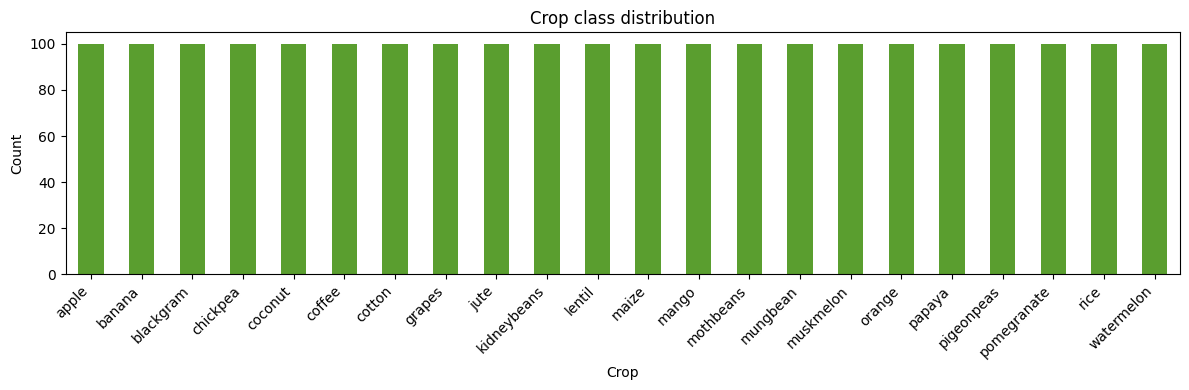

In [7]:
plt.figure(figsize=(12, 4))
label_counts.plot(kind="bar", color="#5a9e2f")
plt.title("Crop class distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 2) Train / Validation / Test Split

Split strategy:
- 80% train+validation / 20% test
- then 75%/25% split inside train+validation (=> 60/20/20 overall)
- stratified by class labels

In [8]:
X = df[FEATURES]
y = df[TARGET]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y_train_val,
)

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (1320, 7) Validation: (440, 7) Test: (440, 7)


## 3) Compare Candidate Models

At least 3 models are compared:
- RandomForest
- GradientBoosting
- ExtraTrees

If `xgboost` is available, it is added as an optional candidate.

In [9]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=450,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        class_weight="balanced",
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.08,
        max_depth=3,
        random_state=RANDOM_SEED,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        class_weight="balanced",
    ),
}

try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
except Exception:
    pass

comparison_rows = []
best_name = None
best_macro_f1 = -1.0
best_accuracy = -1.0

for name, model in models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)

    val_accuracy = accuracy_score(y_val, val_pred)
    val_macro_f1 = f1_score(y_val, val_pred, average="macro")

    comparison_rows.append({
        "name": name,
        "model_class": model.__class__.__name__,
        "val_accuracy": as_float(val_accuracy),
        "val_macro_f1": as_float(val_macro_f1),
    })

    better_macro = val_macro_f1 > best_macro_f1
    tie_better_accuracy = np.isclose(val_macro_f1, best_macro_f1) and val_accuracy > best_accuracy

    if better_macro or tie_better_accuracy:
        best_name = name
        best_macro_f1 = val_macro_f1
        best_accuracy = val_accuracy

comparison_df = pd.DataFrame(comparison_rows).sort_values(["val_macro_f1", "val_accuracy"], ascending=False)
comparison_df

,name,model_class,val_accuracy,val_macro_f1
1,GradientBoosting,GradientBoostingClassifier,0.995455,0.995452
0,RandomForest,RandomForestClassifier,0.990909,0.990903
2,ExtraTrees,ExtraTreesClassifier,0.988636,0.988575


## 4) Retrain Best Model and Evaluate on Test Set

In [10]:
best_model = models[best_name]
best_model.fit(X_train_val, y_train_val)

test_pred = best_model.predict(X_test)
test_accuracy = as_float(accuracy_score(y_test, test_pred))
test_macro_f1 = as_float(f1_score(y_test, test_pred, average="macro"))

print(f"Selected model: {best_name} ({best_model.__class__.__name__})")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test macro F1: {test_macro_f1:.4f}")

Selected model: GradientBoosting (GradientBoostingClassifier)
Test accuracy: 0.9886
Test macro F1: 0.9887


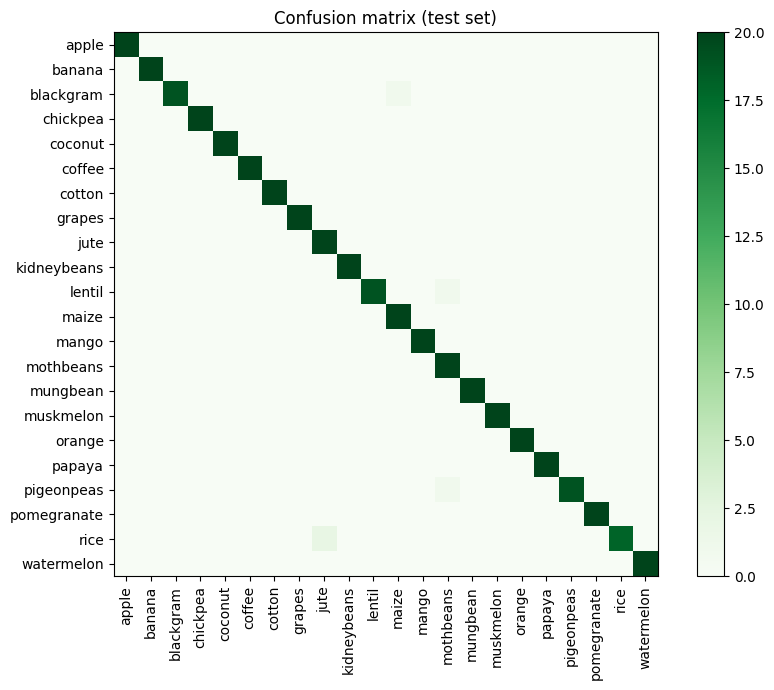

,precision,recall,f1-score,support
apple,1.0,1.00,1.000000,20.0
banana,1.0,1.00,1.000000,20.0
blackgram,1.0,0.95,0.974359,20.0
chickpea,1.0,1.00,1.000000,20.0
coconut,1.0,1.00,1.000000,20.0


In [11]:
labels = sorted(y.unique().tolist())
cm = confusion_matrix(y_test, test_pred, labels=labels)

plt.figure(figsize=(9, 7))
plt.imshow(cm, cmap="Greens")
plt.title("Confusion matrix (test set)")
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.tight_layout()
plt.show()

report = classification_report(y_test, test_pred, labels=labels, output_dict=True, zero_division=0)
pd.DataFrame(report).T.head()

## 5) Explainability Artifacts

We prepare:
- global feature importance
- class profiles (means/std/min/max per feature)
- global feature statistics

In [12]:
if hasattr(best_model, "feature_importances_"):
    feature_values = np.asarray(best_model.feature_importances_, dtype=float)
elif hasattr(best_model, "coef_"):
    coef = np.asarray(best_model.coef_, dtype=float)
    feature_values = np.mean(np.abs(coef), axis=0)
else:
    feature_values = np.ones(len(FEATURES), dtype=float)

feature_values = feature_values / max(feature_values.sum(), 1e-9)
feature_importance = sorted(
    [{"feature": f, "importance": as_float(v)} for f, v in zip(FEATURES, feature_values)],
    key=lambda row: row["importance"],
    reverse=True,
)

importance_df = pd.DataFrame(feature_importance)
importance_df

,feature,importance
0,humidity,0.245833
1,rainfall,0.234183
2,K,0.185090
3,P,0.127373
4,N,0.116597
5,temperature,0.052591
6,ph,0.038332


In [13]:
class_profiles = {}
for crop, group in df.groupby(TARGET):
    class_profiles[str(crop)] = {
        "means": {f: as_float(group[f].mean()) for f in FEATURES},
        "stds": {f: as_float(group[f].std(ddof=0) if not np.isnan(group[f].std(ddof=0)) else 0.0) for f in FEATURES},
        "mins": {f: as_float(group[f].min()) for f in FEATURES},
        "maxs": {f: as_float(group[f].max()) for f in FEATURES},
        "sample_count": int(group.shape[0]),
    }

global_feature_stats = {
    "means": {f: as_float(df[f].mean()) for f in FEATURES},
    "stds": {f: as_float(df[f].std(ddof=0) if not np.isnan(df[f].std(ddof=0)) else 0.0) for f in FEATURES},
    "mins": {f: as_float(df[f].min()) for f in FEATURES},
    "maxs": {f: as_float(df[f].max()) for f in FEATURES},
}

list(class_profiles.keys())[:5], len(class_profiles)

(['apple', 'banana', 'blackgram', 'chickpea', 'coconut'], 22)

## 6) Export Production Artifacts

The following files are exported for Symfony runtime usage:
- `ml/crop_recommendation/best_model.joblib`
- `ml/crop_recommendation/model_metadata.json`

In [14]:
model_path = ARTIFACT_DIR / "best_model.joblib"
metadata_path = ARTIFACT_DIR / "model_metadata.json"

joblib.dump(best_model, model_path)

metadata = {
    "created_at": pd.Timestamp.utcnow().isoformat(),
    "dataset": str(DATASET_PATH.name),
    "random_seed": RANDOM_SEED,
    "feature_names": FEATURES,
    "target_name": TARGET,
    "class_labels": labels,
    "split": {
        "train_size": int(X_train.shape[0]),
        "validation_size": int(X_val.shape[0]),
        "test_size": int(X_test.shape[0]),
    },
    "model_comparison": comparison_rows,
    "selected_model": {
        "name": best_name,
        "model_class": best_model.__class__.__name__,
        "selection_rule": "Highest validation macro_f1, tie-break on validation accuracy",
    },
    "test_metrics": {
        "accuracy": test_accuracy,
        "macro_f1": test_macro_f1,
        "confusion_matrix": {
            "labels": labels,
            "matrix": cm.tolist(),
        },
        "classification_report": report,
    },
    "feature_importance": feature_importance,
    "class_profiles": class_profiles,
    "global_feature_stats": global_feature_stats,
}

with metadata_path.open("w", encoding="utf-8") as fp:
    json.dump(metadata, fp, indent=2)

print("Artifacts exported:")
print("-", model_path)
print("-", metadata_path)

Artifacts exported:
- c:\Users\youss\OneDrive\Bureau\My Projects\symfony-agriculturefinale-20260410-0258\ml\crop_recommendation\best_model.joblib
- c:\Users\youss\OneDrive\Bureau\My Projects\symfony-agriculturefinale-20260410-0258\ml\crop_recommendation\model_metadata.json


C:\Users\youss\AppData\Local\Temp\ipykernel_38684\1599912059.py:7: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "created_at": pd.Timestamp.utcnow().isoformat(),


## 7) Local Explainability + Recommendation Example

This section demonstrates how to produce:
- recommended crop
- confidence and top-N alternatives
- supporting and limiting factors
- agronomic advice

In [15]:
importance_map = {row["feature"]: float(row["importance"]) for row in metadata["feature_importance"]}
global_stds = metadata["global_feature_stats"]["stds"]

def local_explanation(input_features: dict[str, float], predicted_crop: str) -> dict:
    profile = metadata["class_profiles"][predicted_crop]
    means = profile.get("means", {})
    stds = profile.get("stds", {})

    rows = []
    for feature in FEATURES:
        value = float(input_features[feature])
        mean = float(means.get(feature, value))
        std = float(stds.get(feature, 0.0))
        global_std = float(global_stds.get(feature, 1.0))
        scale = max(std, global_std * 0.5, 1e-6)

        z_distance = abs(value - mean) / scale
        alignment = max(0.0, 1.0 - min(z_distance, 3.0) / 3.0)
        weighted_alignment = alignment * float(importance_map.get(feature, 1.0 / len(FEATURES)))

        rows.append({
            "feature": feature,
            "value": as_float(value),
            "class_mean": as_float(mean),
            "alignment": as_float(alignment),
            "z_distance": as_float(z_distance),
            "weighted_alignment": as_float(weighted_alignment),
        })

    supporting = sorted(rows, key=lambda row: row["weighted_alignment"], reverse=True)[:3]
    limiting = sorted(rows, key=lambda row: row["z_distance"], reverse=True)[:2]

    summary = (
        f"{predicted_crop} is recommended because parcel conditions align with learned profiles, "
        f"especially on {supporting[0]['feature']}, {supporting[1]['feature']}, and {supporting[2]['feature']}."
    )

    return {
        "summary": summary,
        "supporting_factors": [
            f"{row['feature']}={row['value']} is close to typical {predicted_crop} conditions (mean {row['class_mean']})."
            for row in supporting
        ],
        "limiting_factors": [
            f"{row['feature']}={row['value']} differs from usual {predicted_crop} profile (mean {row['class_mean']})."
            for row in limiting if row['z_distance'] >= 1.0
        ],
        "feature_alignment": rows,
    }

def agronomic_advice(input_features: dict[str, float], predicted_crop: str) -> list[str]:
    means = metadata["class_profiles"][predicted_crop]["means"]
    advice = []

    rainfall_target = float(means.get("rainfall", input_features["rainfall"]))
    if input_features["rainfall"] < rainfall_target * 0.8:
        advice.append("Rainfall is below typical target for this crop; consider irrigation planning.")
    elif input_features["rainfall"] > rainfall_target * 1.25:
        advice.append("Rainfall is above target; monitor drainage and root oxygenation.")

    ph_target = float(means.get("ph", input_features["ph"]))
    if abs(input_features["ph"] - ph_target) > 0.7:
        advice.append("Soil pH differs from profile; consider pH correction strategy.")

    for nutrient in ["N", "P", "K"]:
        target = float(means.get(nutrient, input_features[nutrient]))
        if input_features[nutrient] < target * 0.8:
            advice.append(f"{nutrient} is lower than profile demand; adjust fertilization before planting.")

    if not advice:
        advice.append("Current conditions are close to target profile; maintain standard monitoring.")

    return advice[:4]

In [16]:
sample_input = {
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 21,
    "humidity": 82,
    "ph": 6.5,
    "rainfall": 203,
}

X_input = pd.DataFrame([[sample_input[f] for f in FEATURES]], columns=FEATURES)
proba = best_model.predict_proba(X_input)[0]
classes = [str(c) for c in best_model.classes_]

top_idx = np.argsort(proba)[::-1][:3]
top_predictions = [
    {"crop": classes[int(i)], "probability": as_float(proba[int(i)])}
    for i in top_idx
]

recommended_crop = top_predictions[0]["crop"]
confidence = top_predictions[0]["probability"]

result = {
    "recommended_crop": recommended_crop,
    "confidence": confidence,
    "top_predictions": top_predictions,
    "explanation": local_explanation(sample_input, recommended_crop),
    "agronomic_advice": agronomic_advice(sample_input, recommended_crop),
}

result

{'recommended_crop': 'rice',
 'confidence': 1.0,
 'top_predictions': [{'crop': 'rice', 'probability': 1.0},
  {'crop': 'jute', 'probability': 0.0},
  {'crop': 'coconut', 'probability': 0.0}],
 'explanation': {'summary': 'rice is recommended because parcel conditions align with learned profiles, especially on humidity, K, and rainfall.',
  'supporting_factors': ['humidity=82.0 is close to typical rice conditions (mean 82.272822).',
   'K=43.0 is close to typical rice conditions (mean 39.87).',
   'rainfall=203.0 is close to typical rice conditions (mean 236.181114).'],
  'limiting_factors': ['temperature=21.0 differs from usual rice profile (mean 23.689332).'],
  'feature_alignment': [{'feature': 'N',
    'value': 90.0,
    'class_mean': 79.89,
    'alignment': 0.817388,
    'z_distance': 0.547835,
    'weighted_alignment': 0.095305},
   {'feature': 'P',
    'value': 42.0,
    'class_mean': 47.58,
    'alignment': 0.887199,
    'z_distance': 0.338403,
    'weighted_alignment': 0.113005}

## 8) Integration Notes (Symfony)

The exported artifacts are consumed by:
- `src/Service/CropRecommendationService.php`

Main integration points:
- parcel recommendation endpoint: `POST /elfirma/parcelles/{id}/recommendation`
- parcel detail UI panel: `templates/elfirma/parcelles/show.html.twig`
- recommendation-to-crop prefill flow:
  - `src/Controller/CultureController.php`
  - `templates/elfirma/cultures/new.html.twig`

Reference scripts used in production pipeline:
- `scripts/ml/train_crop_recommendation.py`
- `scripts/ml/crop_recommendation_infer.py`